In [55]:
import numpy as np
import tqdm as tqdm
import matplotlib.pyplot as plt

In [56]:
MU_0 = 4e-7 * np.pi # магнитная постоянная
EPS_0 = 8.8541878188e-12 # электрическая постоянная
ETA_0 = np.sqrt(MU_0/EPS_0) # волновое сопротивление свободного пространства
C = 1/np.sqrt(MU_0*EPS_0) # скорость света в вакууме

In [57]:
nlamb = 50 # количество точек на одну длину волны
f = 100e6 # частота
lamb = C/f # длина волны
t = 1/f # период
dx = lamb/nlamb # шаг вдоль оси x
dy = lamb/nlamb # шаг вдоль оси y
dz = lamb/nlamb # шаг вдоль оси z
dt = dx/C/np.sqrt(3) # шаг по времени
N_lamb = 1 # количество длин волн в расчетной области
N_t = 1 # количество периодов для моделирования
nx = int(N_lamb*nlamb) # количество точек вдоль оси x
ny = int(N_lamb*nlamb) # количество точек вдоль оси y
nz = int(N_lamb*nlamb) # количество точек вдоль оси z
nt = int(N_t*t/dt) # количество временных шагов
print(f"Шаг по времени: {dt:.2e} с, количество временных шагов: {nt}")

Шаг по времени: 1.15e-10 с, количество временных шагов: 86


In [58]:
def tr(a, dx, dy, dz): #a - массив с нулями по краям
    """ Сдвиг индексов массива a на dx, dy, dz = +1, 0 или -1 """
    mx = a.shape[0] #количество точек вдоль x с учетом крайних слоев
    my = a.shape[1] 
    mz = a.shape[2]
    a[1:-1, 1:-1, 1:-1] = a[1+dx:mx-1+dx, 1+dy:my-1+dy, 1+dz:mz-1+dz]
    return a

In [60]:
# Крайние слои массивов заполнены нулями для реализации сдвига по индексам
Ex = np.zeros((nx+2, ny+2, nz+2))
Ey = np.zeros((nx+2, ny+2, nz+2))
Ez = np.zeros((nx+2, ny+2, nz+2))
Hx = np.zeros((nx+2, ny+2, nz+2))
Hy = np.zeros((nx+2, ny+2, nz+2))
Hz = np.zeros((nx+2, ny+2, nz+2))
sigm = np.zeros((nx+2, ny+2, nz+2))
mu = np.ones((nx+2, ny+2, nz+2))*MU_0
eps = np.ones((nx+2, ny+2, nz+2))*EPS_0

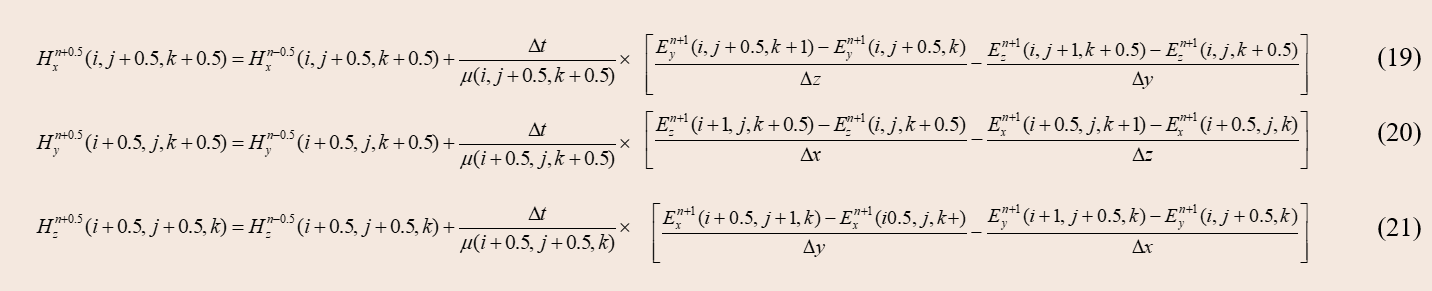

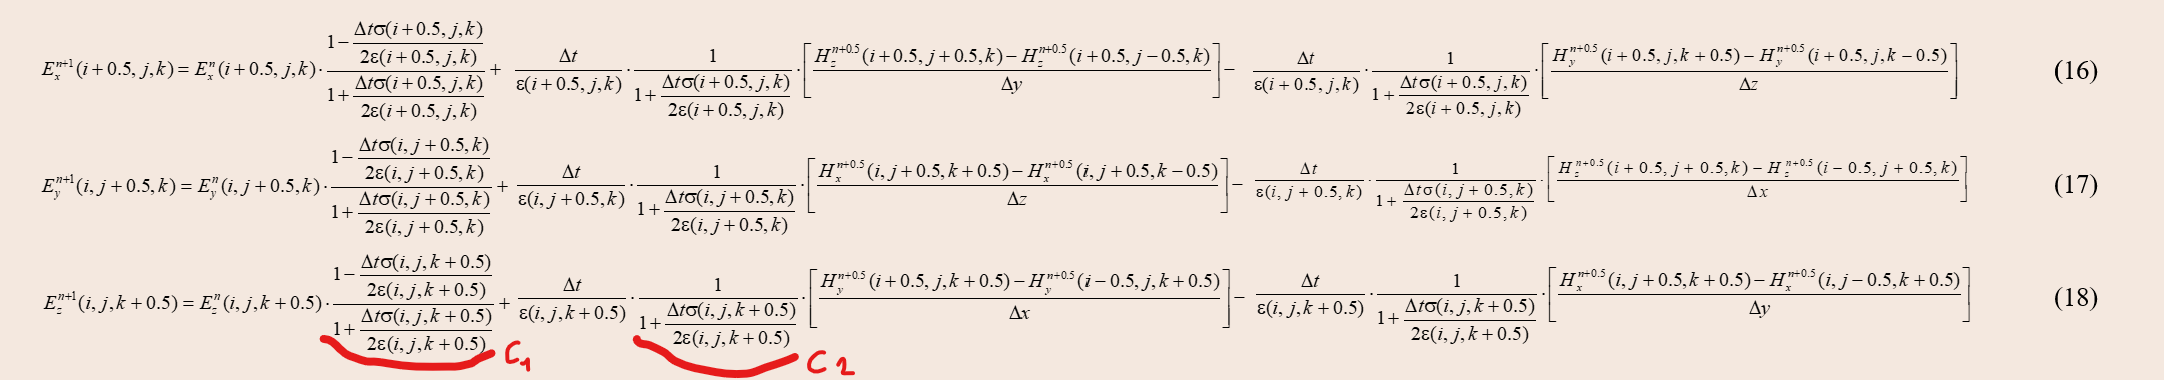

In [61]:
c_1 = (1 - sigm*dt/(2*eps)) / (1 + sigm*dt/(2*eps))
c_2 = 1/(1 + sigm*dt/(2*eps))

In [ ]:
# массив результатов для визуализации
Ez_time = np.zeros((nt, nx, ny))

In [ ]:

for t in tqdm.tqdm(range(nt)):
    # обновление магнитного поля
    Hx = Hx + dt/mu * ((tr(Ey, 0, 0, 1)-tr(Ey, 0, 0, -1))/dz - (tr(Ez, 0, 1, 0)-tr(Ez, 0, -1, 0))/dy)
    Hy = Hy + dt/mu * ((tr(Ez, 1, 0, 0)-tr(Ez, -1, 0, 0))/dx - (tr(Ex, 0, 0, 1)-tr(Ex, 0, 0, -1))/dz)
    Hz = Hz + dt/mu * ((tr(Ex, 0, 1, 0)-tr(Ex, 0, -1, 0))/dy - (tr(Ey, 1, 0, 0)-tr(Ey, -1, 0, 0))/dx)
    # обновление электрического поля
    Ex = c_1*Ex - dt/eps*c_2 * ((tr(Hy, 0, 0, 1)-tr(Hy, 0, 0, -1))/dz - (tr(Hz, 0, 1, 0)-tr(Hz, 0, -1, 0))/dy)
    Ey = c_1*Ey - dt/eps*c_2 * ((tr(Hz, 1, 0, 0)-tr(Hz, -1, 0, 0))/dx - (tr(Hx, 0, 0, 1)-tr(Hx, 0, 0, -1))/dz)
    Ez = c_1*Ez - dt/eps*c_2 * ((tr(Hx, 0, 1, 0)-tr(Hx, 0, -1, 0))/dy - (tr(Hy, 1, 0, 0)-tr(Hy, -1, 0, 0))/dx)
    Ez[nx//2, ny//2, nz//2] = 1.0 * np.sin(2*np.pi*f*dt*nt) # источник в центре расчетной области
    Ez_time[nt] = Ez[1:-1, 1:-1, nz//2] # сохраняем сечение Ez для визуализации

100%|██████████| 86/86 [00:01<00:00, 47.27it/s]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

frames = []

x = np.linspace(0, 2*np.pi, 200)
y = np.linspace(0, 2*np.pi, 200)
X, Y = np.meshgrid(x, y)

for t in range(100):
    Z = np.sin(X + Y + t * 0.1)

    plt.imshow(Z, cmap="viridis", vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f"t={t}")
    
    plt.savefig("frame.png")
    frames.append(imageio.imread("frame.png"))
    plt.clf()

imageio.mimsave("heatmap.gif", frames, fps=20)

C:\Users\Michael\AppData\Local\Temp\ipykernel_22632\4204230144.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread("frame.png"))


<Figure size 640x480 with 0 Axes>

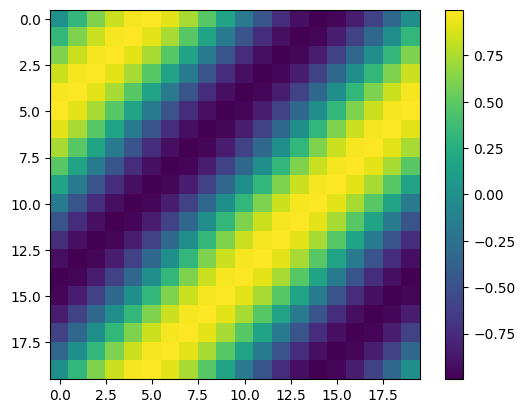

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
HTML(ani.to_jshtml())

# создаём сетку
x = np.linspace(0, 2*np.pi, 20)
y = np.linspace(0, 2*np.pi, 20)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots()
im = ax.imshow(np.sin(X + Y), cmap="viridis", animated=True)
plt.colorbar(im)

def update(frame):
    Z = np.sin(X + Y + frame * 0.1)
    im.set_array(Z)
    return [im]

ani = FuncAnimation(fig, update, frames=100, interval=1)

ani.save("heatmap.gif", writer="pillow", fps=1)